# Analyze statistics of the views dataset

The aim of this notebook is to analyze the statistics of the views dataset. Such analysis will help us to understand the distribution of the users' data. In consequence, we will be able to identify the further steps to transform the data into a more useful format for the recommendation system.

In [1]:
import os
import sys
from datetime import timedelta

import matplotlib.pyplot as plt
import numpy as np
import numpy.typing as npt
import pandas as pd
import seaborn as sns

# Set style for plots
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

CURRENT_DIR = os.path.abspath("")

# NOTE: this has to be before any import from this project (src.*)
# add parent dir to python path
sys.path.append(os.path.join(CURRENT_DIR, ".."))

In [2]:
from src.v2.db_utils import execute_query

LEADS_QUERY = """
select
	dst.create_date,
	dst.algolytics_uuid,
	dst.offer_id,
    dst.property_id,
    dst.view_duration_sec,
    oo.name as offer_name,
    rr.name as region_name,
    rr.full_name_reverted as region_full_name
from
	webrec_stg.dataset_tab_session_time as dst
left join rds2.offers_offer oo on offer_id = oo.id
left join rds2.regions_region as rr on rr.id = oo.region_id
where
    dst.create_date >= '2025-01-01'
    and view_duration_sec > 0
order by
    dst.create_date desc;
"""


async def load_views_data_db() -> pd.DataFrame:
    leads_data = await execute_query(LEADS_QUERY)
    return pd.DataFrame(leads_data)

In [ ]:
DATASET_PATH = os.path.join(CURRENT_DIR, "..", "data", "views.csv")
# NOTE: uncomment if you want to download or refresh the data
# df = await load_views_data_db()
# df.to_csv(DATASET_PATH, index=False)

In [ ]:
# Column name constants
VIEW_DATE = "create_date"
DURATION = "view_duration_sec"
USER_ID = "algolytics_uuid"
INVESTMENT_ID = "offer_id"
APARTMENT_ID = "property_id"
REGION_PATH = "region_full_name"

# Derived column names
CITY = "city"
DAY_OF_WEEK = "day_of_week"
HOUR_OF_DAY = "hour_of_day"
MONTH = "month"
HAS_APARTMENT_VIEW = "has_property_view"
VOIVODESHIP = "voivodeship"
ENGAGEMENT_TIER = "engagement_tier"

In [ ]:
def load_and_prepare_data(file_path: str) -> pd.DataFrame:
    """
    Load and perform initial data preparation.
    """
    print("Loading dataset...")
    # Load the data
    df = pd.read_csv(file_path)

    # Convert date to datetime
    df[VIEW_DATE] = pd.to_datetime(df[VIEW_DATE])

    # Extract additional time features
    df[DAY_OF_WEEK] = df[VIEW_DATE].dt.day_name()
    df[HOUR_OF_DAY] = df[VIEW_DATE].dt.hour
    df[MONTH] = df[VIEW_DATE].dt.month

    # Create a boolean flag for views that have apartment_id (vs. only investment_id)
    df[HAS_APARTMENT_VIEW] = ~df[APARTMENT_ID].isna()

    # Parse region path into separate columns
    if REGION_PATH in df.columns:
        df[VOIVODESHIP] = df[REGION_PATH].apply(lambda x: x.split(", ")[-1] if isinstance(x, str) else None)
        df[CITY] = df[REGION_PATH].apply(lambda x: x.split(", ")[-2] if isinstance(x, str) else None)

    print(f"Dataset loaded with {df.shape[0]} rows and {df.shape[1]} columns")
    return df

In [ ]:
def calculate_gini(array: npt.NDArray) -> float:
    """Helper function to calculate Gini coefficient."""
    # Sort array
    array = np.sort(array)
    n = len(array)
    index = np.arange(1, n + 1)

    # Calculate Gini coefficient
    return float((np.sum((2 * index - n - 1) * array)) / (n * np.sum(array)))

In [ ]:
def basic_statistics(df: pd.DataFrame) -> dict[str, int]:
    """Generate basic statistics about the dataset"""
    print("\n===== BASIC DATASET STATISTICS =====")

    # Overall stats
    total_views = df.shape[0]
    total_users = df[USER_ID].nunique()
    total_investments = df[INVESTMENT_ID].nunique()
    total_apartments = df[APARTMENT_ID].dropna().nunique()
    total_cities = df[CITY].nunique()

    print(f"Total views: {total_views:,}")
    print(f"Unique users: {total_users:,}")
    print(f"Unique investments: {total_investments:,}")
    print(f"Unique apartments: {total_apartments:,}")
    print(f"Unique cities: {total_cities:,}")

    # Time span
    date_range = (df[VIEW_DATE].max() - df[VIEW_DATE].min()).days
    print(f"Date range: {date_range} days from {df[VIEW_DATE].min().date()} to {df[VIEW_DATE].max().date()}")

    # View types
    apt_views = df[HAS_APARTMENT_VIEW].sum()
    inv_only_views = total_views - apt_views
    print(f"Apartment views: {apt_views:,} ({apt_views / total_views:.1%})")
    print(f"Investment-only views: {inv_only_views:,} ({inv_only_views / total_views:.1%})")

    # Duration statistics
    print(
        f"View duration (seconds) - Mean: {df[DURATION].mean():.1f}, Median: {df[DURATION].median():.1f}, "
        f"Min: {df[DURATION].min():.1f}, Max: {df[DURATION].max():.1f}"
    )

    return {
        "total_views": total_views,
        "total_users": total_users,
        "total_investments": total_investments,
        "total_apartments": total_apartments,
    }


def analyze_user_activity(df: pd.DataFrame) -> pd.Series:
    """Analyze user activity patterns"""
    print("\n===== USER ACTIVITY ANALYSIS =====")

    # Views per user statistics
    views_per_user = df.groupby(USER_ID).size()

    print(f"Views per user - Mean: {views_per_user.mean():.1f}, Median: {views_per_user.median():.1f}")
    print(f"Min views per user: {views_per_user.min()}")
    print(f"Max views per user: {views_per_user.max()}")

    # User engagement distribution
    user_counts = pd.DataFrame(
        {"views": views_per_user.value_counts().index, "num_users": views_per_user.value_counts().values}
    ).sort_values("views")

    cumulative_users = user_counts["num_users"].cumsum() / user_counts["num_users"].sum()

    # Find thresholds
    low_activity_threshold = user_counts.loc[cumulative_users >= 0.25, "views"].min()
    high_activity_threshold = user_counts.loc[cumulative_users >= 0.75, "views"].min()

    print(f"25% of users have {low_activity_threshold} or fewer views")
    print(f"75% of users have {high_activity_threshold} or fewer views")

    # User viewing multiple investments/apartments
    users_with_multiple_investments = df.groupby(USER_ID)[INVESTMENT_ID].nunique()
    users_with_multiple_cities = df.groupby(USER_ID)[CITY].nunique()

    print(
        f"Users viewing multiple investments - Mean: {users_with_multiple_investments.mean():.1f}, "
        f"Median: {users_with_multiple_investments.median():.1f}"
    )
    print(
        f"Users viewing multiple cities - Mean: {users_with_multiple_cities.mean():.1f}, "
        f"Median: {users_with_multiple_cities.median():.1f}"
    )

    # Calculate percentage of users with only 1 view
    single_view_users = (views_per_user == 1).sum()
    print(f"Users with only 1 view: {single_view_users:,} ({single_view_users / len(views_per_user):.1%})")

    # Calculate gini coefficient for user activity distribution
    gini = calculate_gini(views_per_user.value_counts().to_numpy())
    print(f"User activity concentration (Gini coefficient): {gini:.2f} (0=perfectly equal, 1=completely unequal)")

    # Return user activity distribution for plotting
    return views_per_user


def analyze_property_popularity(df: pd.DataFrame) -> pd.Series:
    """Analyze property popularity patterns"""
    print("\n===== PROPERTY POPULARITY ANALYSIS =====")

    # Investment popularity
    investment_views = df.groupby(INVESTMENT_ID).size()

    print(f"Views per investment - Mean: {investment_views.mean():.1f}, Median: {investment_views.median():.1f}")
    print(f"Min views per investment: {investment_views.min()}")
    print(f"Max views per investment: {investment_views.max()}")

    # Apartment popularity (filtering out NaN values)
    apartment_df = df.dropna(subset=[APARTMENT_ID])
    if not apartment_df.empty:
        apartment_views = apartment_df.groupby(APARTMENT_ID).size()

        print(f"Views per apartment - Mean: {apartment_views.mean():.1f}, Median: {apartment_views.median():.1f}")
        print(f"Min views per apartment: {apartment_views.min()}")
        print(f"Max views per apartment: {apartment_views.max()}")

        # Percentage of apartments with only 1 view
        single_view_apts = (apartment_views == 1).sum()
        print(f"Apartments with only 1 view: {single_view_apts:,} ({single_view_apts / len(apartment_views):.1%})")

    # Long tail analysis for investments
    investment_cumulative = investment_views.sort_values(ascending=False).cumsum() / investment_views.sum()
    top_10_pct_investments = (investment_cumulative <= 0.1).sum()
    top_50_pct_investments = (investment_cumulative <= 0.5).sum()

    print(
        f"Top {top_10_pct_investments} investments ({top_10_pct_investments / len(investment_views):.1%}) account for 10% of all views"
    )
    print(
        f"Top {top_50_pct_investments} investments ({top_50_pct_investments / len(investment_views):.1%}) account for 50% of all views"
    )

    return investment_views


def analyze_geographic_distribution(df: pd.DataFrame) -> pd.Series:
    """Analyze geographic distribution of views"""
    print("\n===== GEOGRAPHIC DISTRIBUTION ANALYSIS =====")

    # City-level distribution
    city_views = df.groupby(CITY).size().sort_values(ascending=False)

    # Calculate Gini coefficient for city distribution
    gini = calculate_gini(city_views.to_numpy())

    print("Top 5 cities by views:")
    for i, (city, views) in enumerate(city_views.head(5).items(), 1):
        print(f"{i}. {city}: {views:,} views ({views / len(df):.1%} of total)")

    print(f"\nCity concentration (Gini coefficient): {gini:.2f} (0=perfectly equal, 1=completely unequal)")

    # Calculate city distribution quartiles
    city_quartiles = np.percentile(city_views, [25, 50, 75, 90])
    print(
        f"City view quartiles: 25%: {city_quartiles[0]:.0f}, 50%: {city_quartiles[1]:.0f}, "
        f"75%: {city_quartiles[2]:.0f}, 90%: {city_quartiles[3]:.0f}"
    )

    # Regional analysis if available
    if VOIVODESHIP in df.columns:
        region_views = df.groupby(VOIVODESHIP).size().sort_values(ascending=False)

        print("\nTop 5 regions (voivodeships) by views:")
        for i, (region, views) in enumerate(region_views.head(5).items(), 1):
            print(f"{i}. {region}: {views:,} views ({views / len(df):.1%} of total)")

    return city_views


def analyze_temporal_patterns(df: pd.DataFrame) -> dict[str, pd.Series]:
    """Analyze temporal patterns in the data"""
    print("\n===== TEMPORAL PATTERNS ANALYSIS =====")

    # Activity by day of week
    dow_counts = df[DAY_OF_WEEK].value_counts()
    ordered_days = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
    dow_counts = dow_counts.reindex(ordered_days)

    print("Views by day of week:")
    for day in ordered_days:
        if day in dow_counts:
            print(f"{day}: {dow_counts[day]:,} ({dow_counts[day] / len(df):.1%})")

    # Activity by hour of day
    hour_counts = df[HOUR_OF_DAY].value_counts().sort_index()

    peak_hour = hour_counts.idxmax()
    peak_hour_pct = hour_counts[peak_hour] / hour_counts.sum()

    print(f"\nPeak viewing hour: {peak_hour}:00 ({peak_hour_pct:.1%} of views)")

    # Monthly trends
    if df[VIEW_DATE].max() - df[VIEW_DATE].min() > timedelta(days=60):
        monthly_views = df.groupby(df[VIEW_DATE].dt.to_period("M")).size()
        print("\nMonthly view trends:")
        for month, count in monthly_views.items():
            print(f"{month}: {count:,} views")

    return {"dow_counts": dow_counts, "hour_counts": hour_counts}


def analyze_engagement(df: pd.DataFrame) -> pd.Series:
    """Analyze engagement metrics based on view duration"""
    print("\n===== ENGAGEMENT ANALYSIS =====")

    # Define engagement tiers based on duration
    df[ENGAGEMENT_TIER] = pd.cut(
        df[DURATION],
        bins=[0, 30, 60, 120, 600, 1800, 3600, float("inf")],
        labels=[
            "Very Short (<30s)",
            "Short (30-60s)",
            "Medium (1-2min)",
            "Long (2-10min)",
            "Very Long (10-30min)",
            "Extended (30-60min)",
            "Very Extended (>60min)",
        ],
    )

    engagement_counts = df[ENGAGEMENT_TIER].value_counts()

    print("View duration distribution:")
    for tier, count in engagement_counts.items():
        print(f"{tier}: {count:,} views ({count / len(df):.1%})")

    # Very short views might indicate bounces/accidental clicks
    bounce_rate = engagement_counts.get("Very Short (<30s)", 0) / len(df)
    print(f"\nPotential 'bounce' rate (views <30s): {bounce_rate:.1%}")

    # Check if long duration views are evenly distributed across cities
    top_cities = df[CITY].value_counts().head(5).index

    print("\nEngagement by top cities (% of views >30s):")
    for city in top_cities:
        city_df = df[df[CITY] == city]
        long_views = city_df[city_df[DURATION] > 30].shape[0]
        pct_long = long_views / city_df.shape[0]
        print(f"{city}: {pct_long:.1%}")

    return engagement_counts


def analyze_data_sparsity(df: pd.DataFrame, basic_stats: dict[str, int]) -> dict[str, float]:
    """Analyze data sparsity for collaborative filtering"""
    print("\n===== DATA SPARSITY ANALYSIS =====")

    total_users = basic_stats["total_users"]
    total_investments = basic_stats["total_investments"]

    # Calculate theoretical matrix size and density
    theoretical_matrix_size = total_users * total_investments
    actual_interactions = df.shape[0]
    density = actual_interactions / theoretical_matrix_size

    print("User-Investment Matrix:")
    print(
        f"Theoretical matrix size: {total_users:,} users × {total_investments:,} investments = {theoretical_matrix_size:,} cells"
    )
    print(f"Actual interactions: {actual_interactions:,}")
    print(f"Matrix density: {density:.4%}")

    # Calculate average unique investments per user
    avg_investments_per_user = df.groupby(USER_ID)[INVESTMENT_ID].nunique().mean()

    # Calculate average unique users per investment
    avg_users_per_investment = df.groupby(INVESTMENT_ID)[USER_ID].nunique().mean()

    print(f"Average unique investments viewed per user: {avg_investments_per_user:.1f}")
    print(f"Average unique users per investment: {avg_users_per_investment:.1f}")

    # If apartment data is available
    if APARTMENT_ID in df.columns and not df[APARTMENT_ID].isna().all():
        apartment_df = df.dropna(subset=[APARTMENT_ID])
        total_apartments = basic_stats["total_apartments"]

        theoretical_apt_matrix_size = total_users * total_apartments
        actual_apt_interactions = apartment_df.shape[0]
        apt_density = actual_apt_interactions / theoretical_apt_matrix_size

        print("\nUser-Apartment Matrix:")
        print(
            f"Theoretical matrix size: {total_users:,} users × {total_apartments:,} apartments = {theoretical_apt_matrix_size:,} cells"
        )
        print(f"Actual interactions: {actual_apt_interactions:,}")
        print(f"Matrix density: {apt_density:.4%}")

    # Calculate cold start statistics
    users_with_single_view = (df.groupby(USER_ID).size() == 1).sum()
    investments_with_single_view = (df.groupby(INVESTMENT_ID).size() == 1).sum()

    print("\nCold Start Analysis:")
    print(f"Users with only 1 view: {users_with_single_view:,} ({users_with_single_view / total_users:.1%})")
    print(
        f"Investments with only 1 view: {investments_with_single_view:,} ({investments_with_single_view / total_investments:.1%})"
    )

    return {
        "density": density,
        "cold_start_users_pct": users_with_single_view / total_users,
        "cold_start_investments_pct": investments_with_single_view / total_investments,
    }


def generate_plots(
    df: pd.DataFrame,
    views_per_user: pd.Series,
    investment_views: pd.Series,
    city_views: pd.Series,
    temporal_data: dict[str, pd.Series],
    sparsity_data: dict[str, float],
) -> None:
    """Generate various plots for the data analysis"""
    print("\n===== GENERATING PLOTS =====")

    # Create a directory for plots if it doesn't exist
    import os

    if not os.path.exists("plots"):
        os.makedirs("plots")

    # 1. User activity distribution (log scale)
    plt.figure(figsize=(10, 6))
    sns.histplot(views_per_user, log_scale=(False, True), bins=50)
    plt.title("Distribution of Views per User (Log Scale)")
    plt.xlabel("Number of Views")
    plt.ylabel("Number of Users (log scale)")
    plt.tight_layout()
    # plt.savefig("plots/user_activity_distribution.png")

    # 2. Investment popularity distribution (log scale)
    plt.figure(figsize=(10, 6))
    sns.histplot(investment_views, log_scale=(False, True), bins=50)
    plt.title("Distribution of Views per Investment (Log Scale)")
    plt.xlabel("Number of Views")
    plt.ylabel("Number of Investments (log scale)")
    plt.tight_layout()
    # plt.savefig("plots/investment_popularity_distribution.png")

    # 3. City distribution (top 20)
    plt.figure(figsize=(12, 8))
    city_views.head(20).sort_values().plot(kind="barh")
    plt.title("Views by City (Top 20)")
    plt.xlabel("Number of Views")
    plt.tight_layout()
    # plt.savefig("plots/city_distribution.png")

    # 4. Day of week activity
    if "dow_counts" in temporal_data:
        plt.figure(figsize=(10, 6))
        temporal_data["dow_counts"].plot(kind="bar")
        plt.title("Views by Day of Week")
        plt.xlabel("Day of Week")
        plt.ylabel("Number of Views")
        plt.tight_layout()
        # plt.savefig("plots/day_of_week_activity.png")

    # 5. Hour of day activity
    if "hour_counts" in temporal_data:
        plt.figure(figsize=(12, 6))
        temporal_data["hour_counts"].plot(kind="line", marker="o")
        plt.title("Views by Hour of Day")
        plt.xlabel("Hour of Day")
        plt.ylabel("Number of Views")
        plt.xticks(range(0, 24))
        plt.grid(True)
        plt.tight_layout()
        # plt.savefig("plots/hour_of_day_activity.png")

    # 6. View duration distribution
    plt.figure(figsize=(10, 6))
    sns.histplot(df[DURATION].clip(0, 300), bins=30)  # Clip at 5 minutes for better visualization
    plt.title("View Duration Distribution (capped at 5 minutes)")
    plt.xlabel("Duration (seconds)")
    plt.ylabel("Number of Views")
    plt.tight_layout()
    # plt.savefig("plots/duration_distribution.png")

    # 7. Correlation heatmap for numeric features
    numeric_cols = [DURATION, HOUR_OF_DAY]
    if len(numeric_cols) > 1:
        plt.figure(figsize=(8, 6))
        sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm")
        plt.title("Correlation Heatmap")
        plt.tight_layout()
        # plt.savefig("plots/correlation_heatmap.png")

    # 8. Data sparsity visualization
    fig, ax = plt.subplots(figsize=(8, 6))
    sparsity = sparsity_data["density"] * 100
    ax.bar(["Filled Cells", "Empty Cells"], [sparsity, 100 - sparsity])
    ax.set_ylabel("Percentage")
    ax.set_title("User-Investment Matrix Sparsity")
    for i, v in enumerate([sparsity, 100 - sparsity]):
        ax.text(i, v / 2, f"{v:.4f}%", ha="center")
    plt.tight_layout()
    # plt.savefig("plots/matrix_sparsity.png")

    print("Plots saved to './plots/' directory")


def recommend_data_preparation(df: pd.DataFrame, sparsity_data: dict[str, float]) -> pd.DataFrame:
    """Provide recommendations for data preparation based on analysis"""
    print("\n===== RECOMMENDATIONS FOR DATA PREPARATION =====")

    # Threshold recommendations based on data distribution
    views_per_user = df.groupby(USER_ID).size()
    views_per_investment = df.groupby(INVESTMENT_ID).size()

    user_threshold = max(2, views_per_user.quantile(0.9))
    investment_threshold = max(2, views_per_investment.quantile(0.9))

    # 1. Address sparsity
    print("1. Addressing Data Sparsity:")
    print(f"   - Current matrix density: {sparsity_data['density']:.4%}")
    print(f"   - Recommended minimum user activity threshold: {user_threshold:.0f} views")
    print(f"   - Recommended minimum investment popularity threshold: {investment_threshold:.0f} views")

    filtered_users = views_per_user[views_per_user >= user_threshold].index
    filtered_investments = views_per_investment[views_per_investment >= investment_threshold].index

    filtered_df = df[df[USER_ID].isin(filtered_users) & df[INVESTMENT_ID].isin(filtered_investments)]
    new_density = filtered_df.shape[0] / (len(filtered_users) * len(filtered_investments))

    users_removed = len(views_per_user) - len(filtered_users)
    investments_removed = len(views_per_investment) - len(filtered_investments)
    views_removed = len(df) - len(filtered_df)

    print(f"   - After filtering, matrix density would be: {new_density:.4%}")
    print(
        f"   - This would remove {users_removed:,} users ({users_removed / len(views_per_user):.1%}) and "
        f"{investments_removed:,} investments ({investments_removed / len(views_per_investment):.1%})"
    )
    print(f"   - Views removed: {views_removed:,} ({views_removed / len(df):.1%})")

    # 2. Handle geographic imbalance
    city_views = df.groupby(CITY).size()
    # sort by views and take top 5 cities
    city_views = city_views.sort_values(ascending=False)
    top_city_views = city_views.head(5).sum()

    print("\n2. Handling Geographic Imbalance:")
    print(f"   - Top 5 cities account for {top_city_views:,} views ({top_city_views / len(df):.1%} of all views)")

    if top_city_views / len(df) > 0.5:
        print("   - RECOMMENDATION: Consider geographic stratification or city-based normalization")
        print("   - Apply market-size normalization to prevent big-city dominance")

    # 3. Engagement-based filtering
    low_engagement_views = df[df[DURATION] < 10].shape[0]

    print("\n3. Engagement-Based Filtering:")
    print(f"   - Very short views (<10s): {low_engagement_views:,} ({low_engagement_views / len(df):.1%})")

    if low_engagement_views / len(df) > 0.2:
        print("   - RECOMMENDATION: Filter out very short views (<10s) as potential noise")

    # 4. Time decay considerations
    date_range = (df[VIEW_DATE].max() - df[VIEW_DATE].min()).days

    print("\n4. Time Decay Considerations:")
    print(f"   - Data spans {date_range} days")

    if date_range > 90:
        print("   - RECOMMENDATION: Apply time decay to give more weight to recent interactions")

    # 5. Cold start strategies
    cold_start_users_pct = sparsity_data.get("cold_start_users_pct", 0)

    print("\n5. Cold Start Strategies:")
    print(f"   - Users with only 1 view: {cold_start_users_pct:.1%}")

    if cold_start_users_pct > 0.3:
        print("   - RECOMMENDATION: Implement robust cold start strategies using location data")
        print("   - Consider hybrid content-based approaches leveraging your region path data")

    # 6. Feature engineering suggestions
    print("\n6. Feature Engineering Suggestions:")
    print("   - Create engagement score from view duration (e.g., log transformation of duration)")
    print("   - Extract time-of-day preferences (morning/afternoon/evening)")
    print("   - Generate location preference features from the region_path hierarchy")
    print("   - Consider session-based features (sequential views within short timeframes)")

    return filtered_df

In [ ]:
# Load and prepare data
df = load_and_prepare_data(DATASET_PATH)

Loading dataset...
Dataset loaded with 2176447 rows and 14 columns


In [45]:
# Run analyses
basic_stats = basic_statistics(df)


===== BASIC DATASET STATISTICS =====
Total views: 2,176,447
Unique users: 158,616
Unique investments: 10,260
Unique apartments: 48,237
Unique cities: 341
Date range: 30 days from 2025-01-01 to 2025-01-31
Apartment views: 956,365 (43.9%)
Investment-only views: 1,220,082 (56.1%)
View duration (seconds) - Mean: 6403.0, Median: 61.7, Min: 0.0, Max: 21887415.7


In [54]:
views_per_user = analyze_user_activity(df)


===== USER ACTIVITY ANALYSIS =====
Views per user - Mean: 13.7, Median: 4.0
Min views per user: 1
Max views per user: 9337
25% of users have 2 or fewer views
75% of users have 10 or fewer views
Users viewing multiple investments - Mean: 2.3, Median: 1.0
Users viewing multiple cities - Mean: 1.2, Median: 1.0
Users with only 1 view: 23,225 (14.6%)
User activity concentration (Gini coefficient): 0.96 (0=perfectly equal, 1=completely unequal)


In [47]:
investment_views = analyze_property_popularity(df)


===== PROPERTY POPULARITY ANALYSIS =====
Views per investment - Mean: 212.1, Median: 9.0
Min views per investment: 1
Max views per investment: 9816
Views per apartment - Mean: 19.8, Median: 8.0
Min views per apartment: 1
Max views per apartment: 1636
Apartments with only 1 view: 2,947 (6.1%)
Top 41 investments (0.4%) account for 10% of all views
Top 412 investments (4.0%) account for 50% of all views


In [59]:
city_views = analyze_geographic_distribution(df)


===== GEOGRAPHIC DISTRIBUTION ANALYSIS =====
Top 5 cities by views:
1. Warszawa: 576,065 views (26.5% of total)
2. Kraków: 253,793 views (11.7% of total)
3. Łódź: 174,967 views (8.0% of total)
4. Wrocław: 173,549 views (8.0% of total)
5. Gdańsk: 131,299 views (6.0% of total)

City concentration (Gini coefficient): 0.93 (0=perfectly equal, 1=completely unequal)
City view quartiles: 25%: 39, 50%: 297, 75%: 1328, 90%: 5996

Top 5 regions (voivodeships) by views:
1. mazowieckie: 750,069 views (34.5% of total)
2. małopolskie: 275,283 views (12.6% of total)
3. dolnośląskie: 207,099 views (9.5% of total)
4. łódzkie: 194,345 views (8.9% of total)
5. pomorskie: 191,270 views (8.8% of total)


In [60]:
temporal_data = analyze_temporal_patterns(df)


===== TEMPORAL PATTERNS ANALYSIS =====
Views by day of week:
Monday: 325,716 (15.0%)
Tuesday: 310,788 (14.3%)
Wednesday: 345,065 (15.9%)
Thursday: 348,422 (16.0%)
Friday: 321,484 (14.8%)
Saturday: 232,808 (10.7%)
Sunday: 292,164 (13.4%)

Peak viewing hour: 13:00 (7.1% of views)


In [61]:
engagement_counts = analyze_engagement(df)


===== ENGAGEMENT ANALYSIS =====
View duration distribution:
Very Short (<30s): 763,268 views (35.1%)
Long (2-10min): 435,019 views (20.0%)
Short (30-60s): 312,365 views (14.4%)
Medium (1-2min): 285,839 views (13.1%)
Very Long (10-30min): 164,831 views (7.6%)
Very Extended (>60min): 147,708 views (6.8%)
Extended (30-60min): 67,417 views (3.1%)

Potential 'bounce' rate (views <30s): 35.1%

Engagement by top cities (% of views >30s):
Warszawa: 66.9%
Kraków: 68.5%
Łódź: 66.2%
Wrocław: 66.9%
Gdańsk: 65.3%


In [62]:
sparsity_data = analyze_data_sparsity(df, basic_stats)


===== DATA SPARSITY ANALYSIS =====
User-Investment Matrix:
Theoretical matrix size: 158,616 users × 10,260 investments = 1,627,400,160 cells
Actual interactions: 2,176,447
Matrix density: 0.1337%
Average unique investments viewed per user: 2.3
Average unique users per investment: 35.3

User-Apartment Matrix:
Theoretical matrix size: 158,616 users × 48,237 apartments = 7,651,159,992 cells
Actual interactions: 956,365
Matrix density: 0.0125%

Cold Start Analysis:
Users with only 1 view: 23,225 (14.6%)
Investments with only 1 view: 775 (7.6%)



===== GENERATING PLOTS =====
Plots saved to './plots/' directory


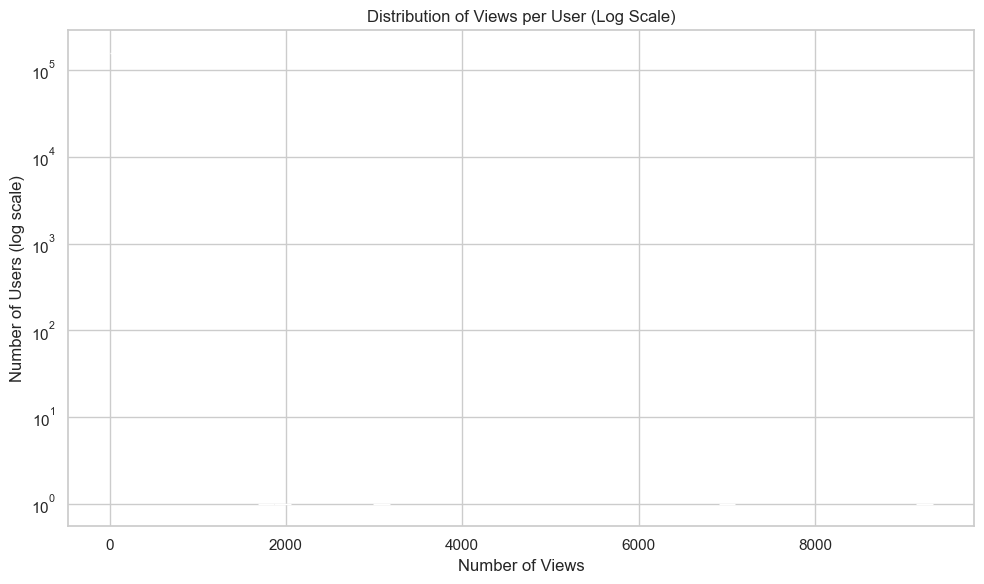

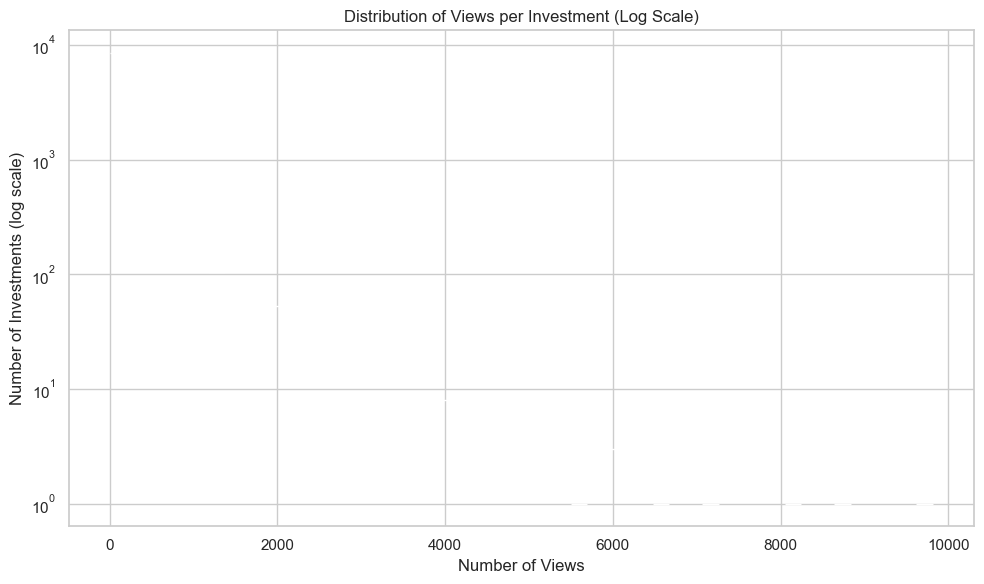

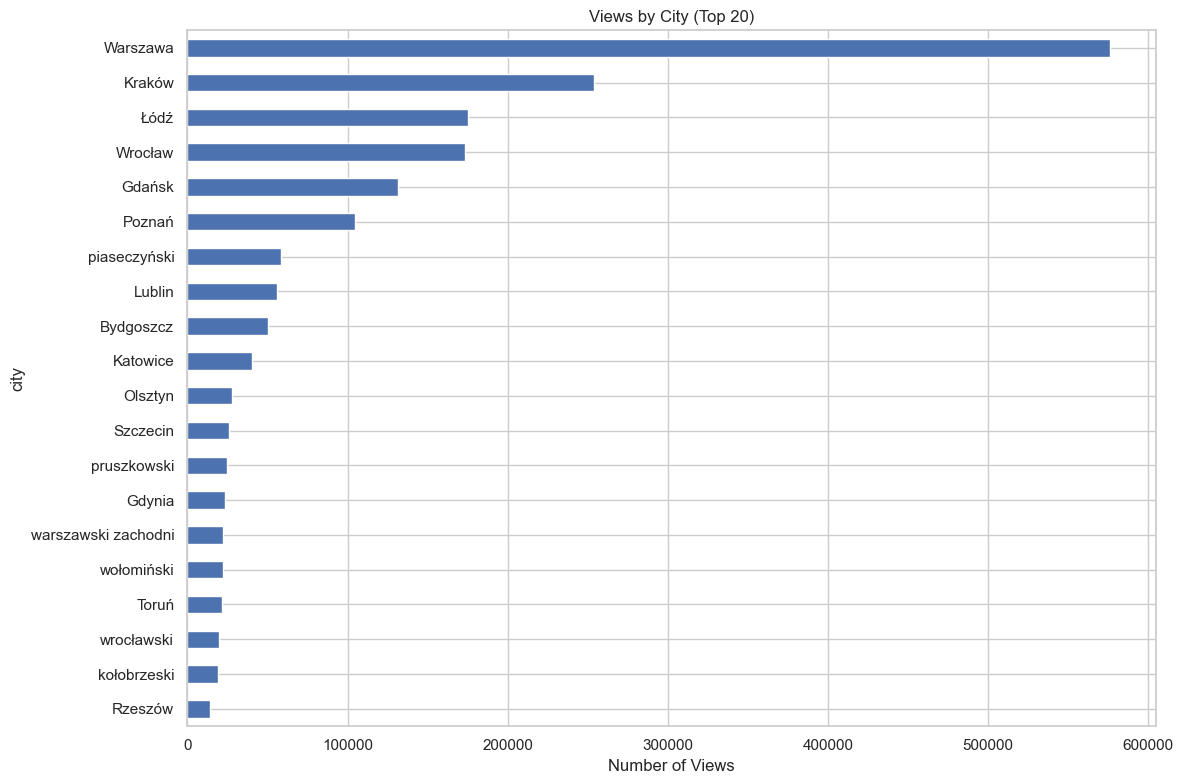

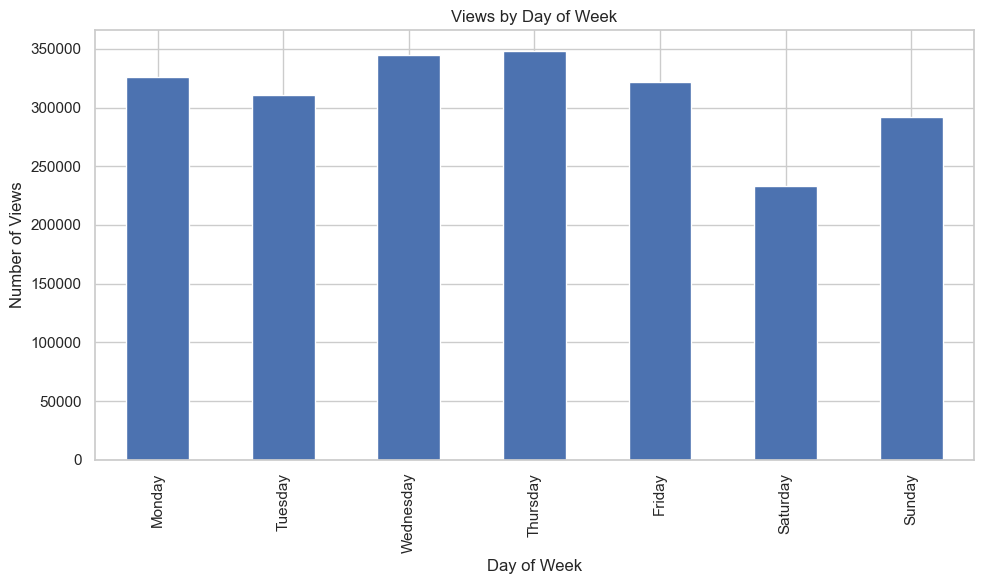

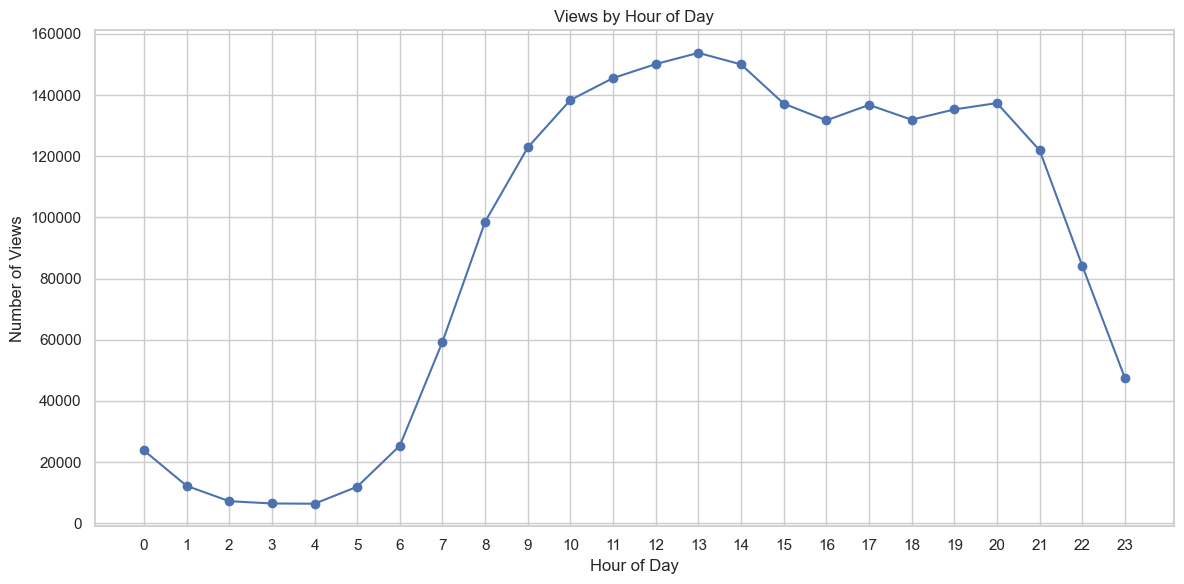

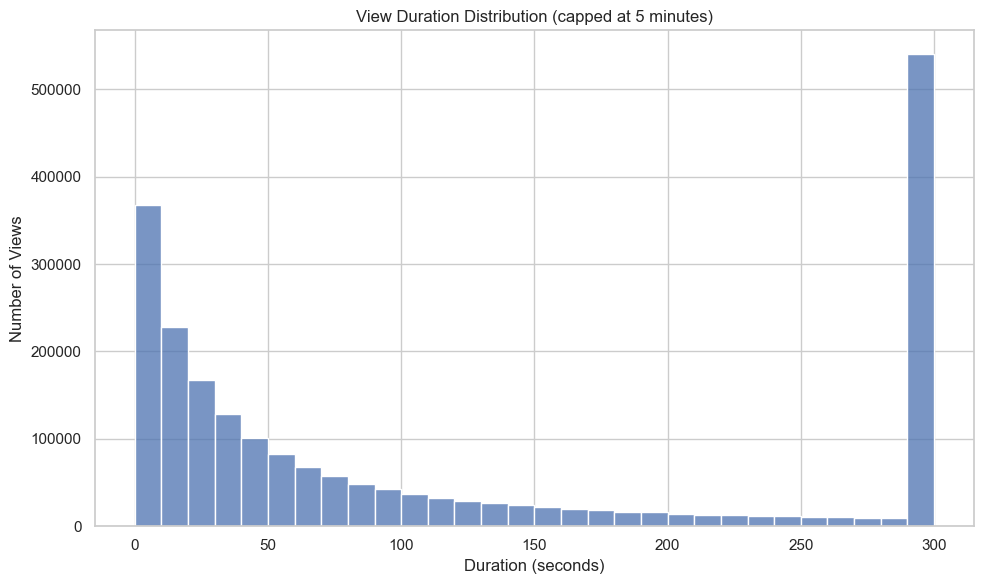

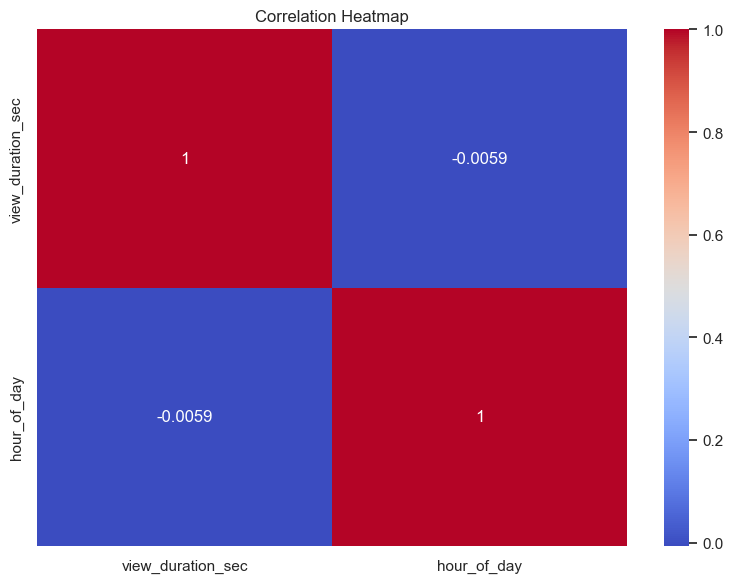

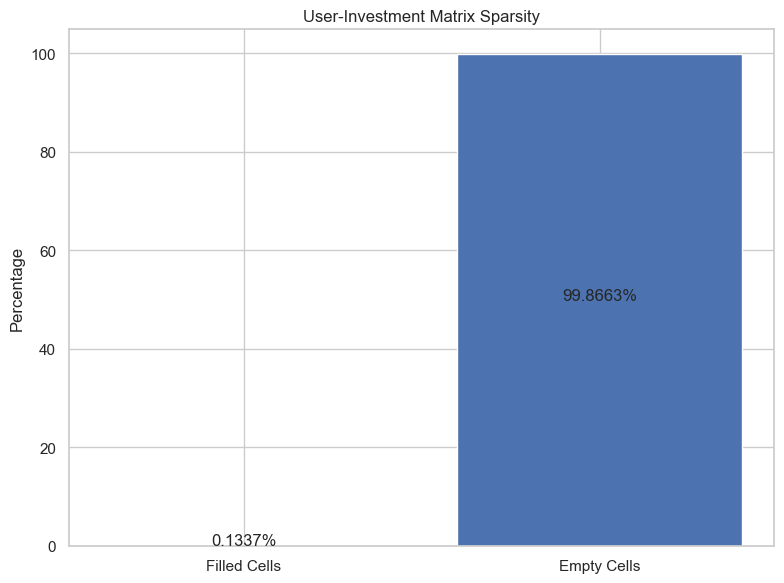

In [63]:
# Generate plots
generate_plots(df, views_per_user, investment_views, city_views, temporal_data, sparsity_data)

In [65]:
# Provide recommendations
filtered_db = recommend_data_preparation(df, sparsity_data)

print("\nAnalysis complete. Review the plots in the 'plots' directory for visualizations.")
print("Based on the findings, adjust your data preparation strategy before implementing collaborative filtering.")



===== RECOMMENDATIONS FOR DATA PREPARATION =====
1. Addressing Data Sparsity:
   - Current matrix density: 0.1337%
   - Recommended minimum user activity threshold: 27 views
   - Recommended minimum investment popularity threshold: 685 views
   - After filtering, matrix density would be: 7.0312%
   - This would remove 142,476 users (89.8%) and 9,233 investments (90.0%)
   - Views removed: 1,010,967 (46.5%)

2. Handling Geographic Imbalance:
   - Top 5 cities account for 1,309,673 views (60.2% of all views)
   - RECOMMENDATION: Consider geographic stratification or city-based normalization
   - Apply market-size normalization to prevent big-city dominance

3. Engagement-Based Filtering:
   - Very short views (<10s): 367,197 (16.9%)

4. Time Decay Considerations:
   - Data spans 30 days

5. Cold Start Strategies:
   - Users with only 1 view: 14.6%

6. Feature Engineering Suggestions:
   - Create engagement score from view duration (e.g., log transformation of duration)
   - Extract time

<b>NOTE:</b> Above recommendations, use 0.9 quantile to filter out the outliers (define if the code). Such cut-off yields quite a decent matrix density in comparison to the original dataset.

# Further analysis

This section implements several metrics to measure users' geographic focus when viewing real estate investments. This will potentially to asses whether a recommendation engine based on location would be effective.

In [ ]:
import os
from collections import Counter, defaultdict
from typing import Any

import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from tqdm import tqdm


def calculate_same_location_ratio(df: pd.DataFrame) -> pd.DataFrame:
    """Calculate the ratio of consecutive views in the same location for each user."""
    results: list[dict[str, Any]] = []

    for user_id, user_df in tqdm(df.groupby(USER_ID), desc="Calculating same location ratio"):
        if len(user_df) <= 1:
            continue

        # Calculate same city and same voivodeship for consecutive views
        user_df["prev_city"] = user_df[CITY].shift(1)
        user_df["prev_voivodeship"] = user_df[VOIVODESHIP].shift(1)

        user_df = user_df.dropna(subset=["prev_city", "prev_voivodeship"])

        same_city_count = (user_df[CITY] == user_df["prev_city"]).sum()
        same_voivodeship_count = (user_df[VOIVODESHIP] == user_df["prev_voivodeship"]).sum()
        total_transitions = len(user_df)

        results.append(
            {
                "user_id": user_id,
                "same_city_ratio": same_city_count / total_transitions if total_transitions > 0 else 0,
                "same_voivodeship_ratio": same_voivodeship_count / total_transitions if total_transitions > 0 else 0,
                "view_count": len(user_df) + 1,  # +1 to include the first view
            }
        )

    return pd.DataFrame(results)


def calculate_geographic_diversity(df: pd.DataFrame) -> pd.DataFrame:
    """Calculate geographic diversity scores for each user."""
    results: list[dict[str, Any]] = []

    for user_id, user_df in tqdm(df.groupby(USER_ID), desc="Calculating geographic diversity"):
        total_views = len(user_df)
        unique_cities = user_df[CITY].nunique()
        unique_voivodeships = user_df[VOIVODESHIP].nunique()

        results.append(
            {
                "user_id": user_id,
                "city_diversity": unique_cities / total_views if total_views > 0 else 0,
                "voivodeship_diversity": unique_voivodeships / total_views if total_views > 0 else 0,
                "unique_cities": unique_cities,
                "unique_voivodeships": unique_voivodeships,
                "total_views": total_views,
            }
        )

    return pd.DataFrame(results)


def calculate_gini_coefficient(df: pd.DataFrame) -> pd.DataFrame:
    """Calculate Gini coefficient for concentration of views across locations."""
    results: list[dict[str, Any]] = []

    for user_id, user_df in tqdm(df.groupby(USER_ID), desc="Calculating Gini coefficient"):
        # City Gini
        city_counts = user_df[CITY].value_counts().values
        if len(city_counts) > 1:
            city_gini = calculate_gini(city_counts)
        else:
            city_gini = 1.0  # Perfect concentration if only one city

        # Voivodeship Gini
        voivodeship_counts = user_df[VOIVODESHIP].value_counts().values
        if len(voivodeship_counts) > 1:
            voivodeship_gini = calculate_gini(voivodeship_counts)
        else:
            voivodeship_gini = 1.0  # Perfect concentration if only one voivodeship

        results.append({"user_id": user_id, "city_gini": city_gini, "voivodeship_gini": voivodeship_gini})

    return pd.DataFrame(results)


def create_transition_matrix(df: pd.DataFrame, location_type: str = CITY) -> pd.DataFrame:
    """Create transition probability matrix for locations."""
    all_transitions: dict[str, Counter] = defaultdict(Counter)

    df = df.sort_values(VIEW_DATE)

    for _, user_df in tqdm(df.groupby(USER_ID), desc="Creating transition matrix"):
        if len(user_df) <= 1:
            continue

        locations = user_df[location_type].tolist()

        for i in range(len(locations) - 1):
            current_loc = locations[i]
            next_loc = locations[i + 1]
            if current_loc != next_loc:
                all_transitions[current_loc][next_loc] += 1

    # Convert to probability matrix
    transition_df = pd.DataFrame()

    for current_loc, next_locs in tqdm(all_transitions.items(), desc="Converting to DataFrame"):
        total = sum(next_locs.values())
        for next_loc, count in next_locs.items():
            transition_df = pd.concat(
                [
                    transition_df,
                    pd.DataFrame(
                        {
                            "current_location": [current_loc],
                            "next_location": [next_loc],
                            "count": [count],
                            "probability": [count / total],
                        }
                    ),
                ]
            )

    return transition_df.reset_index(drop=True)


def evaluate_location_prediction(df: pd.DataFrame, location_type: str = CITY) -> dict[str, float]:
    """Evaluate how well previous location predicts next location."""
    # Prepare data: for each user, create sequences of locations
    sequences: list[tuple[str, str]] = []

    for user_id, user_df in df.groupby(USER_ID):
        if len(user_df) <= 1:
            continue

        locations = user_df[location_type].tolist()

        for i in range(len(locations) - 1):
            sequences.append((locations[i], locations[i + 1]))

    if not sequences:
        return {"accuracy": 0, "precision": 0, "recall": 0, "sample_size": 0}

    # Split into training and testing sets
    train_seq, test_seq = train_test_split(sequences, test_size=0.3, random_state=42)

    # Build transition probability model from training data
    transition_probs: dict[str, dict[str, float]] = {}

    for current_loc, next_loc in train_seq:
        if current_loc not in transition_probs:
            transition_probs[current_loc] = {}

        if next_loc not in transition_probs[current_loc]:
            transition_probs[current_loc][next_loc] = 0

        transition_probs[current_loc][next_loc] += 1

    # Convert counts to probabilities
    for current_loc in transition_probs:
        total = sum(transition_probs[current_loc].values())
        for next_loc in list(transition_probs[current_loc].keys()):
            transition_probs[current_loc][next_loc] /= total

    # Make predictions on test data
    y_true: list[str] = [next_loc for curr_loc, next_loc in test_seq if curr_loc is not None and next_loc is not None]
    y_pred: list[str] = []

    for current_loc, next_loc_true in test_seq:
        if current_loc is None or next_loc_true is None:
            continue
        elif current_loc in transition_probs and transition_probs[current_loc]:
            # Predict the location with highest probability
            prediction = max(transition_probs[current_loc].items(), key=lambda x: x[1])[0]
        else:
            # Fallback prediction: most common next location in training data
            next_locs = [next_loc for _, next_loc in train_seq]
            prediction = Counter(next_locs).most_common(1)[0][0]

        y_pred.append(prediction)

    # Calculate metrics
    accuracy = float(accuracy_score(y_true, y_pred))

    # For multi-class classification, we need to specify average method
    precision = float(precision_score(y_true, y_pred, average="weighted", zero_division=0))
    recall = float(recall_score(y_true, y_pred, average="weighted", zero_division=0))

    return {"accuracy": accuracy, "precision": precision, "recall": recall, "sample_size": len(test_seq)}


def calculate_user_session_metrics(df: pd.DataFrame, session_timeout_minutes: int = 30) -> pd.DataFrame:
    """Calculate metrics for user sessions based on time between views."""
    results: list[dict[str, Any]] = []

    for user_id, user_df in tqdm(df.groupby(USER_ID), desc="Calculating session metrics"):
        if len(user_df) <= 1:
            continue

        # Sort by timestamp
        user_df = user_df.sort_values(VIEW_DATE)

        # Convert timestamp to datetime if it's not already
        if pd.api.types.is_string_dtype(user_df[VIEW_DATE]):
            user_df[VIEW_DATE] = pd.to_datetime(user_df[VIEW_DATE])

        # Calculate time between consecutive views
        user_df["next_view_time"] = user_df[VIEW_DATE].shift(-1)
        user_df["time_to_next_view"] = (user_df["next_view_time"] - user_df[VIEW_DATE]).dt.total_seconds() / 60

        # Identify session breaks (where time between views exceeds timeout)
        user_df["new_session"] = (user_df["time_to_next_view"] > session_timeout_minutes) | (
            user_df["time_to_next_view"].isna()
        )
        user_df["session_id"] = user_df["new_session"].cumsum()

        # Analyze sessions
        sessions = user_df.groupby("session_id")

        session_counts: dict[str, int] = {
            "total_sessions": len(sessions),
            "single_city_sessions": 0,
            "multi_city_sessions": 0,
            "single_voivodeship_sessions": 0,
            "multi_voivodeship_sessions": 0,
        }

        for _, session in sessions:
            unique_cities = session[CITY].nunique()
            unique_voivodeships = session[VOIVODESHIP].nunique()

            if unique_cities == 1:
                session_counts["single_city_sessions"] += 1
            else:
                session_counts["multi_city_sessions"] += 1

            if unique_voivodeships == 1:
                session_counts["single_voivodeship_sessions"] += 1
            else:
                session_counts["multi_voivodeship_sessions"] += 1

        results.append(
            {
                "user_id": user_id,
                "total_sessions": session_counts["total_sessions"],
                "single_city_session_ratio": session_counts["single_city_sessions"] / session_counts["total_sessions"]
                if session_counts["total_sessions"] > 0
                else 0,
                "single_voivodeship_session_ratio": session_counts["single_voivodeship_sessions"]
                / session_counts["total_sessions"]
                if session_counts["total_sessions"] > 0
                else 0,
            }
        )

    return pd.DataFrame(results)


def analyze_dataset(df: pd.DataFrame, dataset_name: str) -> dict[str, Any]:
    """Main function to analyze the dataset and output metrics."""

    print(f"\nDataset overview: {len(df)} views from {df[USER_ID].nunique()} users")
    print(f"Locations: {df[CITY].nunique()} cities in {df[VOIVODESHIP].nunique()} voivodeships")

    print("\nCalculating same location ratios...")
    location_ratios = calculate_same_location_ratio(df)
    print(f"Average same-city ratio: {location_ratios['same_city_ratio'].mean():.4f}")
    print(f"Average same-voivodeship ratio: {location_ratios['same_voivodeship_ratio'].mean():.4f}")

    print("\nCalculating geographic diversity...")
    diversity = calculate_geographic_diversity(df)
    print(f"Average city diversity: {diversity['city_diversity'].mean():.4f}")
    print(f"Average voivodeship diversity: {diversity['voivodeship_diversity'].mean():.4f}")

    print("\nCalculating Gini coefficients...")
    gini = calculate_gini_coefficient(df)
    print(f"Average city Gini coefficient: {gini['city_gini'].mean():.4f}")
    print(f"Average voivodeship Gini coefficient: {gini['voivodeship_gini'].mean():.4f}")

    print("\nCalculating session-based metrics...")
    session_metrics = calculate_user_session_metrics(df)
    print(f"Average single-city session ratio: {session_metrics['single_city_session_ratio'].mean():.4f}")
    print(f"Average single-voivodeship session ratio: {session_metrics['single_voivodeship_session_ratio'].mean():.4f}")

    print("\nCreating city transition matrix...")
    city_transitions = create_transition_matrix(df, CITY)
    top_transitions = city_transitions.sort_values("count", ascending=False).head(25)
    print("\nTop 25 city transitions:")
    print(top_transitions[["current_location", "next_location", "probability", "count"]])
    most_probable = top_transitions.sort_values("probability", ascending=False).head(25)
    print("\nMost probable city transitions:")
    print(most_probable[["current_location", "next_location", "probability", "count"]])

    print("\nEvaluating location prediction...")
    city_prediction = evaluate_location_prediction(df, CITY)
    voivodeship_prediction = evaluate_location_prediction(df, VOIVODESHIP)

    print(
        f"City prediction metrics: Accuracy={city_prediction['accuracy']:.4f}, "
        f"Precision={city_prediction['precision']:.4f}, Recall={city_prediction['recall']:.4f}"
    )
    print(
        f"Voivodeship prediction metrics: Accuracy={voivodeship_prediction['accuracy']:.4f}, "
        f"Precision={voivodeship_prediction['precision']:.4f}, Recall={voivodeship_prediction['recall']:.4f}"
    )

    # Create combined results dataframe
    results = pd.merge(location_ratios, diversity, on="user_id")
    results = pd.merge(results, gini, on="user_id")
    results = pd.merge(results, session_metrics, on="user_id")

    print("\nSaving results to CSV files...")
    path = os.path.join("..", "logs", "dataset_analysis", dataset_name)
    os.makedirs(path, exist_ok=True)
    results.to_csv(os.path.join(path, "user_geographic_metrics.csv"), index=False)
    city_transitions.to_csv(os.path.join(path, "city_transitions.csv"), index=False)

    return {
        "results": results,
        "city_transitions": city_transitions,
        "city_prediction": city_prediction,
        "voivodeship_prediction": voivodeship_prediction,
    }


def interpret_dataset(df: pd.DataFrame, dataset_name: str) -> None:
    # Replace with your actual file path
    results = analyze_dataset(df, dataset_name)
    print("\nAnalysis complete! Results saved to CSV files.")

    # Interpretation of results
    city_ratio = results["results"]["same_city_ratio"].mean()
    voivodeship_ratio = results["results"]["same_voivodeship_ratio"].mean()
    city_gini = results["results"]["city_gini"].mean()
    single_city_session = results["results"]["single_city_session_ratio"].mean()
    city_prediction = results["city_prediction"]

    print("\nInterpretation of results:")
    if city_ratio > 0.5:
        print("- Users show strong tendency to view properties in the same city")
    elif voivodeship_ratio > 0.7:
        print("- Users primarily stay within the same voivodeship when browsing")

    if single_city_session > 0.8:
        print("- Most user sessions focus on a single city, suggesting strong location focus")

    if city_gini > 0.7:
        print("- High geographic concentration indicates users are very focused on specific locations")
        print("- Location-based recommendations would likely be effective")
    elif city_gini > 0.4:
        print("- Moderate geographic concentration suggests combining location with other features")
    else:
        print("- Low geographic concentration indicates users browse widely across regions")
        print("- Consider features beyond location for your recommendation engine")

    if city_prediction["accuracy"] > 0.6:
        print("- Good city prediction accuracy suggests location is a strong predictor of user behavior")
    else:
        print("- Lower prediction accuracy suggests considering additional features beyond location")


In [42]:
interpret_dataset(df)


Dataset overview: 2176447 views from 158616 users
Locations: 341 cities in 23 voivodeships

Calculating same location ratios...


Calculating same location ratio: 100%|██████████| 158616/158616 [04:24<00:00, 600.32it/s]


Average same-city ratio: 0.9720
Average same-voivodeship ratio: 0.9879

Calculating geographic diversity...


Calculating geographic diversity: 100%|██████████| 158616/158616 [00:31<00:00, 5020.48it/s]


Average city diversity: 0.3680
Average voivodeship diversity: 0.3598

Calculating Gini coefficients...


...

Average city Gini coefficient: 0.9157
Average voivodeship Gini coefficient: 0.9662

Calculating session-based metrics...


Calculating session metrics: 100%|██████████| 158616/158616 [08:35<00:00, 307.92it/s]


Average single-city session ratio: 0.9462
Average single-voivodeship session ratio: 0.9786

Creating city transition matrix...


Converting to DataFrame: 100%|██████████| 336/336 [00:04<00:00, 81.03it/s] 


Top 25 city transitions:
         current_location        next_location  probability
212              Warszawa             Warszawa     0.979159
0                  Kraków               Kraków     0.982437
497                  Łódź                 Łódź     0.984968
628               Wrocław              Wrocław     0.977975
883                Gdańsk               Gdańsk     0.967017
1301               Poznań               Poznań     0.980176
1524               Lublin               Lublin     0.986475
2014         piaseczyński         piaseczyński     0.916435
414             Bydgoszcz            Bydgoszcz     0.985359
2359             Katowice             Katowice     0.956291
2467              Olsztyn              Olsztyn     0.975960
769              Szczecin             Szczecin     0.972313
1422               Gdynia               Gdynia     0.934890
2136          pruszkowski          pruszkowski     0.891597
2708                Toruń                Toruń     0.985118
1241  warszawsk

In [74]:
interpret_dataset(filtered_db, "filtered_dataset")


Dataset overview: 1165480 views from 15591 users
Locations: 88 cities in 16 voivodeships

Calculating same location ratios...


Calculating same location ratio: 100%|██████████| 15591/15591 [00:27<00:00, 564.43it/s]


Average same-city ratio: 0.9713
Average same-voivodeship ratio: 0.9889

Calculating geographic diversity...


Calculating geographic diversity: 100%|██████████| 15591/15591 [00:03<00:00, 4435.79it/s]


Average city diversity: 0.0438
Average voivodeship diversity: 0.0360

Calculating Gini coefficients...


...

Average city Gini coefficient: 0.7905
Average voivodeship Gini coefficient: 0.9070

Calculating session-based metrics...


Calculating session metrics: 100%|██████████| 15591/15591 [01:02<00:00, 247.97it/s]


Average single-city session ratio: 0.8740
Average single-voivodeship session ratio: 0.9510

Creating city transition matrix...


Converting to DataFrame: 100%|██████████| 89/89 [00:00<00:00, 108.97it/s]


Top 25 city transitions:
        current_location        next_location  probability  count
5               Warszawa         piaseczyński     0.229803   1519
333         piaseczyński             Warszawa     0.576394   1509
8               Warszawa           wołomiński     0.153555   1015
658           wołomiński             Warszawa     0.741791    994
0               Warszawa  warszawski zachodni     0.098638    652
78   warszawski zachodni             Warszawa     0.558261    642
688          pruszkowski             Warszawa     0.443651    559
9               Warszawa          pruszkowski     0.083661    553
561               Kraków                 None     0.213217    513
625                 None               Kraków     0.674202    507
968           wrocławski              Wrocław     0.874016    444
273              Wrocław           wrocławski     0.299368    426
739             wielicki               Kraków     0.851324    418
562               Kraków             wielicki     0